<a href="https://colab.research.google.com/github/BrundaSreedhar/credit-card-fraud-detection/blob/main/RandomForestExperiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Experiments

In [39]:
import pandas as pd
import numpy as np

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path
)



Using Colab cache for faster access to the 'creditcardfraud' dataset.


#Data Preprocessing


In [40]:
#Amount ranges from 0 to 25691.160000

from sklearn.preprocessing import RobustScaler, StandardScaler
new_df = df.copy()
new_df['Amount'] = RobustScaler().fit_transform(new_df['Amount'].to_numpy().reshape(-1, 1))

In [41]:
time = new_df['Time']
#standard scaler
new_df['Time'] = StandardScaler().fit_transform(new_df[['Time']])

In [42]:
new_df = new_df.sample(frac=1, random_state=42)

In [43]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    new_df,
    test_size=0.2,
    stratify=new_df['Class'],
    random_state=42
)

test, val = train_test_split(
    temp,
    test_size=0.5,
    stratify=temp['Class'],
    random_state=42
)

In [44]:
x_train = train.drop(columns=['Class'])
y_train = train['Class']

x_test = test.drop(columns=['Class'])
y_test = test['Class']

x_val = val.drop(columns=['Class'])
y_val = val['Class']

x_train.shape, y_train.shape, x_test.shape, y_test.shape, x_val.shape, y_val.shape

((227845, 30), (227845,), (28481, 30), (28481,), (28481, 30), (28481,))

In [82]:
from sklearn.metrics import precision_recall_curve, classification_report, average_precision_score, fbeta_score
import pandas as pd

# Initialize a dictionary to store all model results
model_results = {}

def evaluate_model_and_store_results(model_name, y_true, y_probs, class_names=['Legit', 'Fraud'], beta=1.0):
    """
    Evaluates a model's performance, prints a classification report, and stores key metrics.
    Optimizes for F1-score (or F-beta score if beta is specified) to find the best threshold.

    Args:
        model_name (str): Name of the model for identification.
        y_true (array-like): True labels.
        y_probs (array-like): Predicted probabilities for the positive class.
        class_names (list): List of class names for classification report.
        beta (float): The beta parameter for the F-beta score. beta=1.0 is F1-score.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)

    # Calculate F-beta scores for each threshold
    fbeta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-9)
    best_idx = np.argmax(fbeta)
    best_threshold = thresholds[best_idx]

    y_pred_tuned = (y_probs >= best_threshold).astype(int)

    report = classification_report(y_true, y_pred_tuned, target_names=class_names, output_dict=True)
    pr_auc = average_precision_score(y_true, y_probs)

    # Extract metrics for the 'Fraud' class (class 1)
    fraud_precision = report['Fraud']['precision']
    fraud_recall = report['Fraud']['recall']
    fraud_f1 = report['Fraud']['f1-score']

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Best threshold (optimizing for F{beta:.0f}-score): {best_threshold:.4f}")
    print(classification_report(y_true, y_pred_tuned, target_names=class_names))
    print(f"PR-AUC: {pr_auc:.4f}")

    model_results[model_name] = {
        'PR-AUC': pr_auc,
        'Precision (Fraud)': fraud_precision,
        'Recall (Fraud)': fraud_recall,
        'F1-Score (Fraud)': fraud_f1,
        'Best Threshold': best_threshold
    }


#Modelling

Baseline Random Forest

In [46]:
from sklearn.metrics import precision_recall_curve, classification_report, average_precision_score
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(x_train, y_train)

print(classification_report(y_val, random_forest.predict(x_val), target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.90      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.95      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481



Try threshold tuning on best to maximize F1

In [83]:
y_probs = random_forest.predict_proba(x_val)[:, 1]

# Evaluate with F1-score tuning (default beta=1.0)
evaluate_model_and_store_results(
    'RF (unweighted, full features) - F1 Tuned',
    y_val, y_probs,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'RF (unweighted, full features) - F2 Tuned',
    y_val, y_probs,
    beta=2.0
)


--- RF (unweighted, full features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.3500
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8325

--- RF (unweighted, full features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.1900
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.86      0.86      0.86        49

    accuracy                           1.00     28481
   macro avg       0.93      0.93      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8325


this classifier has pretty good precision, but we'd like to see if we could improve the recall without destroying precision.


Lets try adding class weights:

In [48]:
random_forest_weighted = RandomForestClassifier(class_weight="balanced", random_state=42)
random_forest_weighted.fit(x_train, y_train)

weighted_predictions = random_forest_weighted.predict(x_val)
print(classification_report(y_val, weighted_predictions, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.92      0.71      0.80        49

    accuracy                           1.00     28481
   macro avg       0.96      0.86      0.90     28481
weighted avg       1.00      1.00      1.00     28481



In [84]:
#tune threshold for results from weighted RF
y_probs_weighted = random_forest_weighted.predict_proba(x_val)[:, 1]

# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'RF (weighted, full features) - F1 Tuned',
    y_val, y_probs_weighted,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'RF (weighted, full features) - F2 Tuned',
    y_val, y_probs_weighted,
    beta=2.0
)


--- RF (weighted, full features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.2400
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8202

--- RF (weighted, full features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.2400
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8202


#List Important features

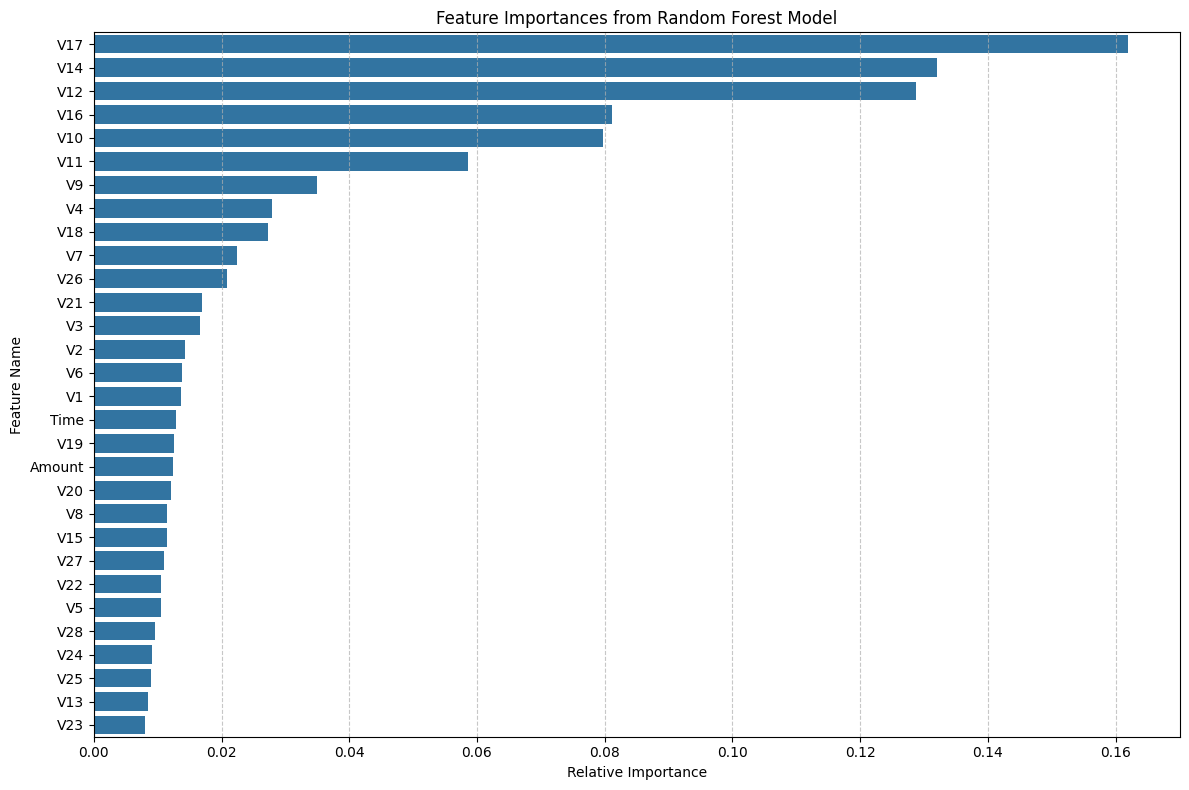

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-obtain feature importances and names from the unweighted Random Forest model
feature_importances = random_forest.feature_importances_
feature_names = x_train.columns
sorted_indices = np.argsort(feature_importances)[::-1]

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names[sorted_indices],
    'Importance': feature_importances[sorted_indices]
})

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest Model')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
#keep just the important features and train the model on them
important_features = feature_names[sorted_indices[:15]]
x_train_important = x_train[important_features]
x_val_important = x_val[important_features]

random_forest_important = RandomForestClassifier(random_state=42)
random_forest_important.fit(x_train_important, y_train)

y_important_predictions = random_forest_important.predict(x_val_important)
print(classification_report(y_val, y_important_predictions, target_names=['Legit', 'Fraud']))



              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.90      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.95      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481



In [85]:
#Tune threshold
y_probs_important_15 = random_forest_important.predict_proba(x_val_important)[:, 1]

# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'RF (unweighted, 15 important features) - F1 Tuned',
    y_val, y_probs_important_15,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'RF (unweighted, 15 important features) - F2 Tuned',
    y_val, y_probs_important_15,
    beta=2.0
)


--- RF (unweighted, 15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.3800
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.84      0.87        49

    accuracy                           1.00     28481
   macro avg       0.96      0.92      0.94     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8170

--- RF (unweighted, 15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.3800
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.84      0.87        49

    accuracy                           1.00     28481
   macro avg       0.96      0.92      0.94     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8170


In [86]:
#Balance the model with 15 important features
random_forest_important_balanced = RandomForestClassifier(class_weight="balanced", random_state=42)
random_forest_important_balanced.fit(x_train_important, y_train)

y_important_predictions_balanced = random_forest_important_balanced.predict(x_val_important)
print(classification_report(y_val, y_important_predictions_balanced, target_names=['Legit', 'Fraud']))

#threhold tuning
y_probs_important_balanced = random_forest_important_balanced.predict_proba(x_val_important)[:, 1]

# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'RF (balanced, 15 important features) - F1 Tuned',
    y_val, y_probs_important_balanced,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'RF (balanced, 15 important features) - F2 Tuned',
    y_val, y_probs_important_balanced,
    beta=2.0
)

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.94      0.69      0.80        49

    accuracy                           1.00     28481
   macro avg       0.97      0.85      0.90     28481
weighted avg       1.00      1.00      1.00     28481


--- RF (balanced, 15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.2200
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.84      0.87        49

    accuracy                           1.00     28481
   macro avg       0.96      0.92      0.94     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8095

--- RF (balanced, 15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.2200
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.0

In [54]:
#train a regular RF with just the features, random_state = 42

random_forest_unweighted_important = RandomForestClassifier(random_state=42)
random_forest_unweighted_important.fit(x_train_important, y_train)

y_important_predictions_unweighted = random_forest_unweighted_important.predict(x_val_important)
print(classification_report(y_val, y_important_predictions_unweighted, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.90      0.78      0.84        49

    accuracy                           1.00     28481
   macro avg       0.95      0.89      0.92     28481
weighted avg       1.00      1.00      1.00     28481



In [87]:
#threshold tune the results
y_probs = random_forest_unweighted_important.predict_proba(x_val_important)[:, 1]

# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'RF (unweighted, important features) - F1 Tuned',
    y_val, y_probs,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'RF (unweighted, important features) - F2 Tuned',
    y_val, y_probs,
    beta=2.0
)


--- RF (unweighted, important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.3800
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.84      0.87        49

    accuracy                           1.00     28481
   macro avg       0.96      0.92      0.94     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8170

--- RF (unweighted, important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.3800
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.84      0.87        49

    accuracy                           1.00     28481
   macro avg       0.96      0.92      0.94     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8170


In [56]:
#hyperparameter tuning Random Forest
tuned_rf1 = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=4,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42
    )
tuned_rf1.fit(x_train_important, y_train)

y_tuned_rf1 = tuned_rf1.predict(x_val_important)
y_probas_rf1 = tuned_rf1.predict_proba(x_val_important)[:, 1]


--- Tuned RF (balanced, 15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.3592
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.7976

--- Tuned RF (balanced, 15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.3592
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.7976


In [88]:
# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'Tuned RF (balanced, 15 important features) - F1 Tuned',
    y_val, y_probas_rf1,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'Tuned RF (balanced, 15 important features) - F2 Tuned',
    y_val, y_probas_rf1,
    beta=2.0
)


--- Tuned RF (balanced, 15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.3592
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.7976

--- Tuned RF (balanced, 15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.3592
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.7976


In [57]:
#Notbalanced

tuned_rf1_unbalanced = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=42
    )
tuned_rf1_unbalanced.fit(x_train_important, y_train)

y_tuned_rf1_unbalanced = tuned_rf1_unbalanced.predict(x_val_important)
y_probas_rf1_unbalanced = tuned_rf1_unbalanced.predict_proba(x_val_important)[:, 1]


--- Tuned RF (unbalanced, 15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.3839
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.82      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8173

--- Tuned RF (unbalanced, 15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.2881
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.87      0.84      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8173


In [89]:
# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'Tuned RF (unbalanced, 15 important features) - F1 Tuned',
    y_val, y_probas_rf1_unbalanced,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'Tuned RF (unbalanced, 15 important features) - F2 Tuned',
    y_val, y_probas_rf1_unbalanced,
    beta=2.0
)


--- Tuned RF (unbalanced, 15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.3839
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.82      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8173

--- Tuned RF (unbalanced, 15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.2881
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.87      0.84      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8173


Let's try SMOTE + Random Forest


In [58]:
pip install imblearn

In [59]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# define pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42 )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=42
    ))
])

# train (SMOTE applied ONLY to training data)
pipeline.fit(x_train_important, y_train)

# predict
y_pred_smote = pipeline.predict(x_val_important)

print(classification_report(y_val, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.83      0.82      0.82        49

    accuracy                           1.00     28481
   macro avg       0.92      0.91      0.91     28481
weighted avg       1.00      1.00      1.00     28481



In [90]:
y_probs = pipeline.predict_proba(x_val_important)[:, 1]

# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'SMOTE + RF (15 important features) - F1 Tuned',
    y_val, y_probs,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'SMOTE + RF (15 important features) - F2 Tuned',
    y_val, y_probs,
    beta=2.0
)


--- SMOTE + RF (15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.5906
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.82      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8010

--- SMOTE + RF (15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.4907
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.84      0.84      0.84        49

    accuracy                           1.00     28481
   macro avg       0.92      0.92      0.92     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8010


Another experiment with RF + SMOTE

In [61]:
from sklearn.metrics import precision_recall_curve, classification_report, average_precision_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


rf_model = Pipeline([
    ("smote", SMOTE(
        sampling_strategy=0.4,   # not full balance → to prevent overfitting
        k_neighbors=5,
        random_state=42
    )),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=42
    ))
])

#fit model
rf_model.fit(x_train_important, y_train)

y_probs = rf_model.predict_proba(x_val_important)[:, 1]


--- SMOTE (sampling=0.4) + RF (15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.6864
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.93      0.82      0.87        49

    accuracy                           1.00     28481
   macro avg       0.96      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8111

--- SMOTE (sampling=0.4) + RF (15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.5209
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8111


In [91]:
# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'SMOTE (sampling=0.4) + RF (15 important features) - F1 Tuned',
    y_val, y_probs,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'SMOTE (sampling=0.4) + RF (15 important features) - F2 Tuned',
    y_val, y_probs,
    beta=2.0
)



--- SMOTE (sampling=0.4) + RF (15 important features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.5906
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.91      0.82      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8010

--- SMOTE (sampling=0.4) + RF (15 important features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.4907
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.84      0.84      0.84        49

    accuracy                           1.00     28481
   macro avg       0.92      0.92      0.92     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8010


In [63]:
param_dist = {
    "smote__sampling_strategy": [0.2, 0.5, 0.3],  # how much to oversample
    "smote__k_neighbors": [3, 5, 7],

    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [6, 8, 10, None],
    "rf__min_samples_leaf": [1, 2, 4]
}

In [64]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",   # PR-AUC for imbalanced data
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('rf',
                                              RandomForestClassifier(min_samples_leaf=4,
                                                                     n_estimators=200,
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'rf__max_depth': [6, 8, 10, None],
                                        'rf__min_samples_leaf': [1, 2, 4],
                                        'rf__n_estimators': [100, 200, 300],
                                        'smote__k_neighbors': [3, 5, 7],
                                        'smote__sampling_strategy': [0.2, 0.5,
                                                                     0.3]},
                   random_state=42, scoring='average_precision', verbose=1)

In [65]:
print("Best PR-AUC:", search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_

Best PR-AUC: 0.8594185205450261
Best params: {'smote__sampling_strategy': 0.3, 'smote__k_neighbors': 5, 'rf__n_estimators': 300, 'rf__min_samples_leaf': 1, 'rf__max_depth': None}


In [66]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

final_model = Pipeline([
    ("smote", SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

In [67]:
final_model.fit(x_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42, sampling_strategy=0.3)),
                ('rf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [101]:
from sklearn.metrics import classification_report, average_precision_score

y_pred = final_model.predict(x_val)
y_probs = final_model.predict_proba(x_val)[:, 1]

# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'Hyperparameter Tuned SMOTE + RF (all features) - F1 Tuned',
    y_val, y_probs,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'Hyperparameter Tuned SMOTE + RF (all features) - F2 Tuned',
    y_val, y_probs,
    beta=2.0
)


--- Hyperparameter Tuned SMOTE + RF (all features) - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.4667
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8294

--- Hyperparameter Tuned SMOTE + RF (all features) - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.4667
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8294


In [69]:
#gridsearchCV

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 8, 10, None],
    "min_samples_leaf": [1, 2, 4, 8],
    "class_weight": [None, "balanced"]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,                   # ⭐ only try 10 random combos
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(x_train_important, y_train)

print("Best PR-AUC:", search.best_score_)
print("Best params:", search.best_params_)

print("Best Estimator", search.best_estimator_)

Best PR-AUC: 0.8432890703010539
Best params: {'n_estimators': 100, 'min_samples_leaf': 4, 'max_depth': None, 'class_weight': None}
Best Estimator RandomForestClassifier(min_samples_leaf=4, random_state=42)


In [99]:
#run on validation set
y_probs_randomsearch = search.best_estimator_.predict_proba(x_val_important)[:, 1]
y_probs_untuned = search.best_estimator_.predict(x_val_important)

# Evaluate with F1-score tuning
evaluate_model_and_store_results(
    'Random Search on Important features - F1 Tuned',
    y_val, y_probs_randomsearch,
    beta=1.0
)

# Evaluate with F2-score tuning
evaluate_model_and_store_results(
    'Random Search on Importnat Features - F2 Tuned',
    y_val, y_probs_randomsearch,
    beta=2.0
)


--- Random Search on Important features - F1 Tuned Evaluation ---
Best threshold (optimizing for F1-score): 0.2716
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.87      0.84      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8158

--- Random Search on Importnat Features - F2 Tuned Evaluation ---
Best threshold (optimizing for F2-score): 0.2716
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     28432
       Fraud       0.87      0.84      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

PR-AUC: 0.8158
              precision    recall  f1-score   support

           0       1.00      

In [98]:
y_eval_test_probs = search.best_estimator_.predict_proba(x_test[important_features])[:, 1]
y_pred_test = (y_eval_test_probs >= 0.27).astype(int)
print(classification_report(y_test, y_pred_test))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.89      0.80      0.84        49

    accuracy                           1.00     28481
   macro avg       0.94      0.90      0.92     28481
weighted avg       1.00      1.00      1.00     28481



### Understanding the Precision-Recall Curve and PR-AUC

A **Precision-Recall (PR) Curve** illustrates the trade-off between precision and recall for different threshold settings. Precision is the ratio of true positive predictions to the total positive predictions (`TP / (TP + FP)`), while Recall is the ratio of true positive predictions to all actual positives (`TP / (TP + FN)`).

In the context of highly imbalanced datasets like fraud detection, the PR curve is often more informative than the Receiver Operating Characteristic (ROC) curve. This is because the ROC curve can present an overly optimistic view of an algorithm's performance if there is a large class imbalance.

**PR-AUC (Area Under the Precision-Recall Curve)** is a single scalar value that summarizes the performance of the model across all possible thresholds. A higher PR-AUC indicates better performance, as it means the model is achieving high precision and high recall simultaneously. For fraud detection, a high PR-AUC is desirable, as it signifies that the model can effectively identify fraudulent transactions (high recall) without generating too many false alarms (high precision).

### Model Performance Comparison

In [102]:
import pandas as pd

# Convert the model_results dictionary to a pandas DataFrame for better visualization
results_df = pd.DataFrame.from_dict(model_results, orient='index')

# Sort by Recall (Fraud) in descending order
results_df_sorted = results_df.sort_values(by='Recall (Fraud)', ascending=False)

# Display the DataFrame
display(results_df_sorted.round(4))

print("\nBased on the comprehensive evaluation, you can now review the performance of each model on the validation and test sets. Compare the PR-AUC, Precision (Fraud), Recall (Fraud), and F1-Score (Fraud) to make an informed decision on which model is best suited for your specific fraud detection requirements.")

,PR-AUC,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),Best Threshold
"RF (unweighted, full features) - F2 Tuned",0.8325,0.8571,0.8571,0.8571,0.1900
"RF (unweighted, full features) - F1 Tuned",0.8325,0.8913,0.8367,0.8632,0.3500
"RF (weighted, full features) - F1 Tuned",0.8202,0.8913,0.8367,0.8632,0.2400
"RF (weighted, full features) - F2 Tuned",0.8202,0.8913,0.8367,0.8632,0.2400
"RF (unweighted, 15 important features) - F1 Tuned",0.8170,0.9111,0.8367,0.8723,0.3800
"RF (unweighted, 15 important features) - F2 Tuned",0.8170,0.9111,0.8367,0.8723,0.3800
"RF (balanced, 15 important features) - F1 Tuned",0.8095,0.9111,0.8367,0.8723,0.2200
"RF (balanced, 15 important features) - F2 Tuned",0.8095,0.9111,0.8367,0.8723,0.2200
"RF (unweighted, important features) - F1 Tuned",0.8170,0.9111,0.8367,0.8723,0.3800
"RF (unweighted, important features) - F2 Tuned",0.8170,0.9111,0.8367,0.8723,0.3800



Based on the comprehensive evaluation, you can now review the performance of each model on the validation and test sets. Compare the PR-AUC, Precision (Fraud), Recall (Fraud), and F1-Score (Fraud) to make an informed decision on which model is best suited for your specific fraud detection requirements.


##Evaluate

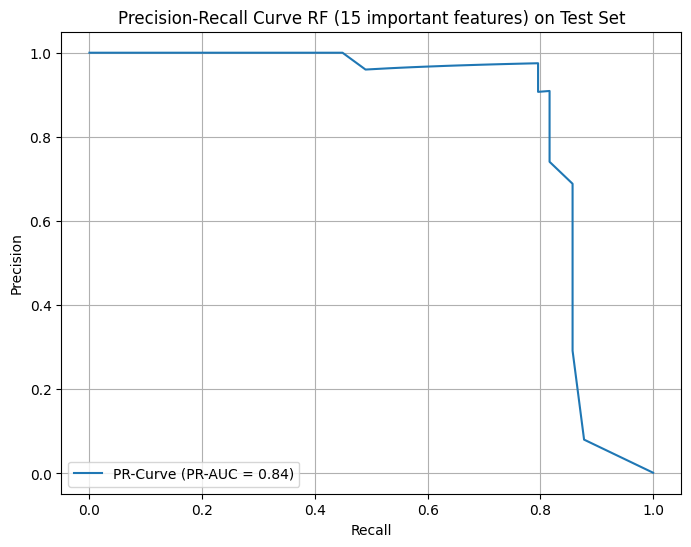

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.91      0.82      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481



In [103]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for the positive class from the best model (rf_model) on the test set
proba_test = random_forest_important_balanced.predict_proba(x_test[important_features])[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test, proba_test)

# Calculate PR-AUC
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR-Curve (PR-AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve RF (15 important features) on Test Set')
plt.legend()
plt.grid(True)
plt.show()

y_pred_test = (proba_test >= 0.2200).astype(int)
print(classification_report(y_test, y_pred_test))